# 01 · EDA — Inside Airbnb London (2026-06-19 snapshot)

Goal for this notebook: understand the raw data well enough to lock in
**the modelling target, the evaluation metric, and honest baselines** for the
price-prediction pillar, and to sanity-check that the NLP and time-series
pillars are viable.

Questions to answer here:
1. What does the price distribution look like? What target do we model (raw £, log £, price per person)?
2. How much data do we lose to missing / absurd prices, and is that loss biased?
3. Which structured features obviously matter (room type, bedrooms, borough, location)?
4. Do descriptions have enough text to be worth modelling?
5. What's the naive baseline we have to beat (predict the borough median)?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from londonrent.data import build_interim
from londonrent.config import FIGURES

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

df = build_interim()
print(df.shape)
df.head(3)

(92638, 38)


,id,last_scraped,name,description,neighborhood_overview,host_id,host_since,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,number_of_reviews_ltm,reviews_per_month,review_scores_rating,review_scores_location,estimated_occupancy_l365d,first_review,last_review,instant_bookable,license,bathrooms,bath_is_shared,amenity_count,host_days_active
0,11551,2026-06-25,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,43039,NaT,True,1.0,True,Lambeth,51.46095,-0.11758,Entire rental unit,Entire home/apt,5,1 bath,1.0,3.0,"[""Carbon monoxide alarm"", ""Portable air condit...",234.5,1.0,1125.0,330,196,6,0.99,4.55,4.54,55,2010-03-21,2026-06-05,<NA>,NaN,1.0,False,44,NaN
1,13913,2026-06-25,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,54730,NaT,False,2.0,True,Islington,51.56861,-0.11270,Private room in rental unit,Private room,1,1 shared bath,NaN,1.0,"[""Babysitter recommendations"", ""Coffee maker: ...",127.0,1.0,29.0,351,57,3,0.30,4.86,4.79,28,2010-08-18,2026-03-31,<NA>,NaN,1.0,True,45,NaN
2,15400,2026-06-26,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,60302,NaT,False,1.0,True,Kensington and Chelsea,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,"[""Refrigerator"", ""Long term stays allowed"", ""C...",137.5,4.0,30.0,80,98,1,0.49,4.81,4.94,9,2009-12-21,2026-03-30,<NA>,NaN,1.0,False,25,NaN


## 1 · Price: coverage and distribution

In [2]:
n = len(df)
missing = df["price"].isna().mean()
print(f"{n:,} listings · price missing for {missing:.1%}")

price = df["price"].dropna()
print(price.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))

92,638 listings · price missing for 32.8%
count     62240.0
mean       271.47
std        2190.6
min          2.23
1%           35.0
5%          50.75
25%         100.0
50%         180.0
75%        300.03
95%         676.0
99%       1373.46
max      527524.0
Name: price, dtype: Float64


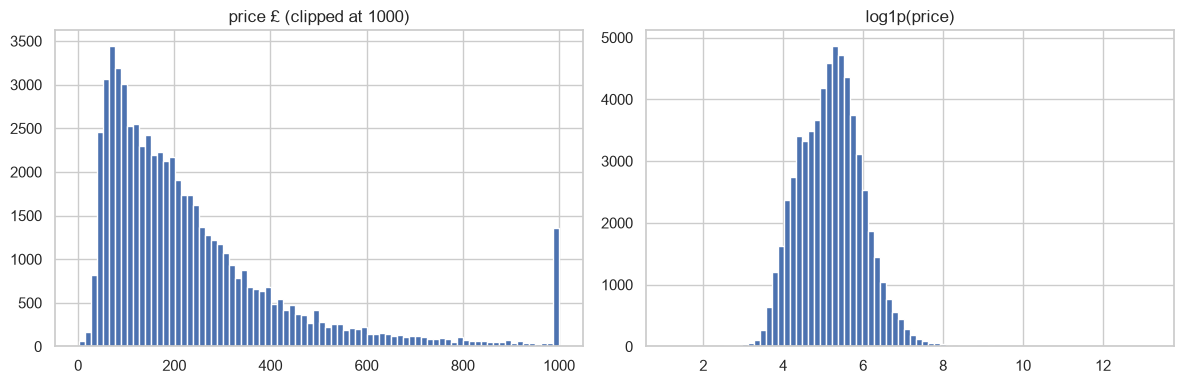

In [3]:
# Raw vs log, with a sane analysis window (Airbnb has data-entry junk in the tails)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
price.clip(upper=1000).hist(bins=80, ax=ax[0]); ax[0].set_title("price £ (clipped at 1000)")
np.log1p(price).hist(bins=80, ax=ax[1]); ax[1].set_title("log1p(price)")
plt.tight_layout()

**Decision to record here:** analysis window for the price target
(e.g. £10–£1000/night, entire-home + private-room only?), and whether the
target is `log(price)` or `price`. Write the choice into the notebook prose
before moving on — the rest of the project depends on it.

## 2 · Is the missing / dropped price biased?

In [4]:
df["price_missing"] = df["price"].isna()
by_room = df.groupby("room_type")["price_missing"].mean().sort_values(ascending=False)
by_boro = df.groupby("neighbourhood_cleansed")["price_missing"].mean().sort_values(ascending=False)
print(by_room, "\n")
print(by_boro.head(10))

room_type
Hotel room         0.400000
Private room       0.357925
Entire home/apt    0.313701
Shared room        0.098522
Name: price_missing, dtype: float64 

neighbourhood_cleansed
Hackney                 0.492356
Islington               0.430737
Lambeth                 0.407303
Tower Hamlets           0.405291
Lewisham                0.394524
Haringey                0.387366
Southwark               0.386540
Wandsworth              0.380559
Waltham Forest          0.363538
Richmond upon Thames    0.350040
Name: price_missing, dtype: float64


## 3 · Structured features vs price

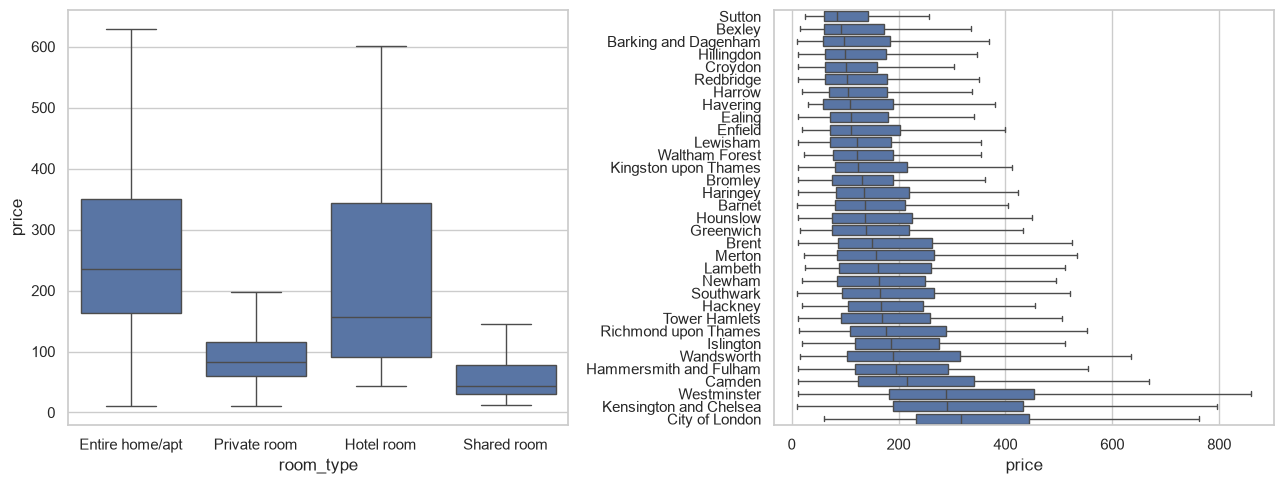

In [5]:
work = df[df["price"].between(10, 1000)].copy()
work["log_price"] = np.log(work["price"])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(work, x="room_type", y="price", ax=ax[0], showfliers=False)
order = work.groupby("neighbourhood_cleansed")["price"].median().sort_values().index
sns.boxplot(work, y="neighbourhood_cleansed", x="price", order=order, ax=ax[1], showfliers=False)
ax[1].set_ylabel("")
plt.tight_layout()

In [6]:
num = ["accommodates", "bedrooms", "beds", "bathrooms", "amenity_count",
       "minimum_nights", "number_of_reviews", "review_scores_rating",
       "review_scores_location", "host_days_active"]
corr = work[num + ["log_price"]].corr(numeric_only=True)["log_price"].sort_values()
corr

minimum_nights           -0.120596
number_of_reviews        -0.104707
review_scores_rating      0.055650
review_scores_location    0.137848
bathrooms                 0.305342
amenity_count             0.331011
bedrooms                  0.438928
beds                      0.463543
accommodates              0.612319
log_price                 1.000000
host_days_active               NaN
Name: log_price, dtype: float64

Text(0, 0.5, 'latitude')

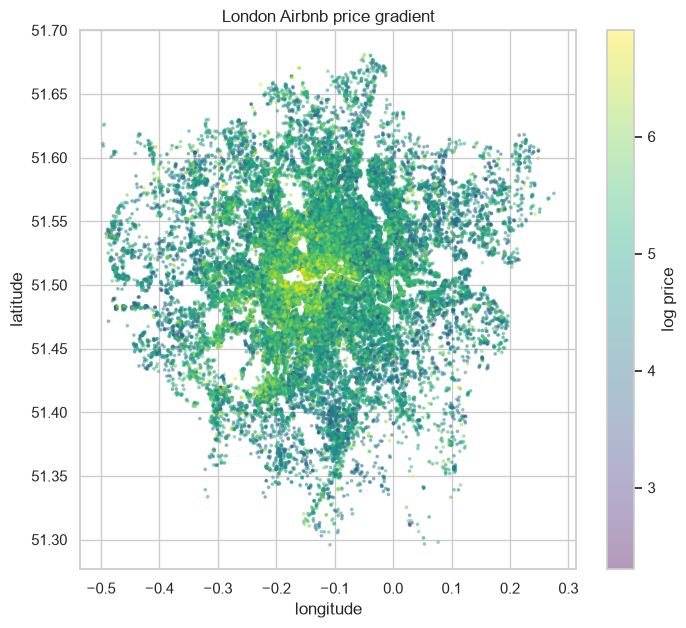

In [7]:
# Location: does a simple lat/long scatter already show the price gradient?
fig, ax = plt.subplots(figsize=(8, 7))
s = ax.scatter(work["longitude"], work["latitude"], c=work["log_price"],
               s=3, alpha=.4, cmap="viridis")
fig.colorbar(s, label="log price"); ax.set_title("London Airbnb price gradient")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

## 4 · Is there enough text for the NLP pillar?

In [8]:
for col in ["description", "neighborhood_overview"]:
    t = df[col].dropna().astype(str)
    wc = t.str.split().str.len()
    print(f"{col}: {df[col].notna().mean():.1%} present · "
          f"median {wc.median():.0f} words · p90 {wc.quantile(.9):.0f}")
print()
print(df["description"].dropna().iloc[0][:400])

description: 97.7% present · median 69 words · p90 87
neighborhood_overview: 0.0% present · median nan words · p90 nan

Live like a local in this quintessential London flat, boasting a well-equipped kitchen for home-cooked feasts, vintage chic with real oil paintings adding a touch of artistic flair, and a buzzing ambience that pulsates with the rhythm of this dynamic neighbourhood.<br />Immerse yourself in the vibrant buzz just outside your door, then hop on the Tube (3 mins!) and conquer London (10 mins away!). D


## 5 · Baselines to beat

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

w = work.dropna(subset=["log_price"]).copy()
global_med = w["log_price"].median()
boro_med = w.groupby("neighbourhood_cleansed")["log_price"].transform("median")
roomboro_med = w.groupby(["neighbourhood_cleansed", "room_type"])["log_price"].transform("median")

for name, pred in [("global median", global_med),
                   ("borough median", boro_med),
                   ("borough × room_type median", roomboro_med)]:
    pred = np.broadcast_to(pred, w["log_price"].shape)
    mae_gbp = mean_absolute_error(np.exp(w["log_price"]), np.exp(pred))
    print(f"{name:28s}  log-MAE={mean_absolute_error(w['log_price'], pred):.3f}  "
          f"£-MAE={mae_gbp:6.1f}  R²={r2_score(w['log_price'], pred):.3f}")

global median                 log-MAE=0.608  £-MAE= 121.4  R²=-0.002
borough median                log-MAE=0.550  £-MAE= 110.8  R²=0.168
borough × room_type median    log-MAE=0.405  £-MAE=  89.6  R²=0.491


### Week-1 exit checklist
- [ ] Target + transform chosen and written down
- [ ] Analysis window (price range, room types) chosen
- [ ] Missing-price bias understood and noted
- [ ] Baseline numbers recorded (the bar for the Week-3 model)
- [ ] NLP pillar confirmed viable (enough text)
- [ ] `data/README.md` filled in with real column notes